# ETA Prediction: Data Preparation and Preprocessing
In hyper-scale ride-sharing platforms, predicting the Estimated Time of Arrival (ETA) is a computationally demanding task. Standard routing engines calculate ETAs based on fixed road segments, invariably failing to capture the dynamic friction of real-world terrain. 

**Goal:** In this notebook, we simulate the `/prepare` endpoint. We will generate synthetic geospatial features, preprocess the data to establish our baseline physical routing ETA, and split the data into structured CSV files (`train.csv`, `validation.csv`, `test.csv`) to prevent data leakage during model training.

**Expected Output:** We expect to generate a clean tabular dataset where the `actual_time` (ground truth) deviates from the `baseline_eta` in a non-linear fashion based on complex feature interactions.

In [1]:
from modules.data_utils import generate_raw_data, load_data, preprocess_data, split_data, store_splits
from visuals.plots import plot_data_distributions

# 1. Generate and load raw data
_ = generate_raw_data('data/raw_data.csv')
df = load_data('data/raw_data.csv')

# 2. Preprocess data (calculate the true residual for visualization)
df = preprocess_data(df)

# 3. Split the data
train_df, val_df, test_df = split_data(df)

# 4. Store the splits
store_splits(train_df, val_df, test_df)

### Data Distribution Analysis
Before moving to modeling, we visualize the target variables. The true residual represents the specific number of seconds that must be added to or subtracted from the baseline ETA to match reality.

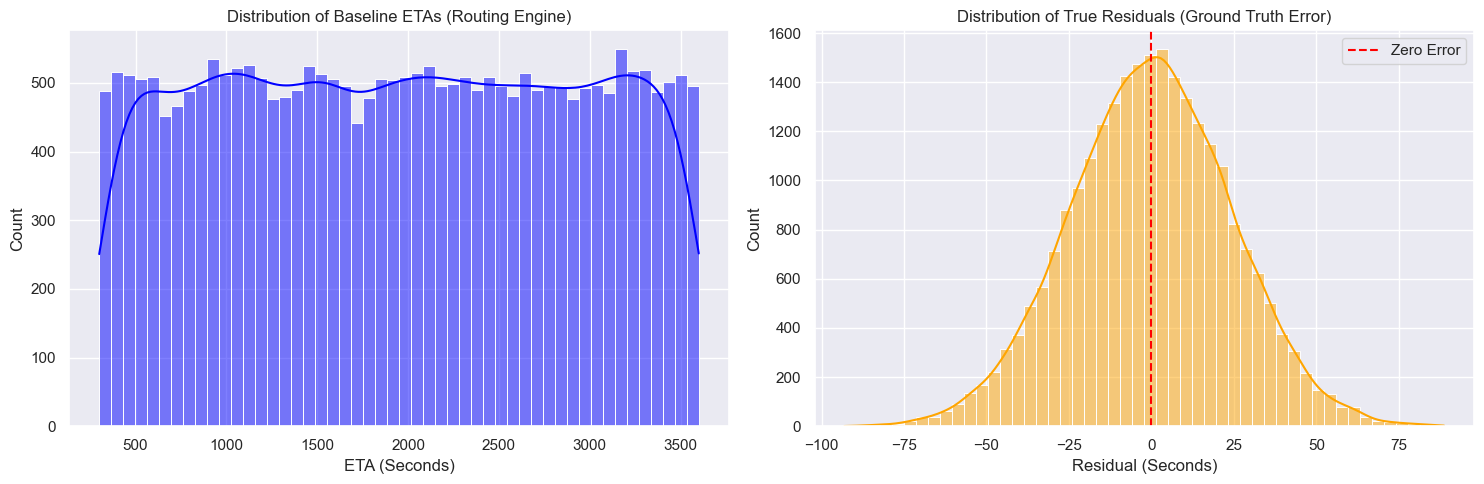

In [2]:
plot_data_distributions(df['baseline_eta'], df['true_residual'])

**Interpretation:** The routing engine provides a wide, uniform distribution of ETAs across various trips. However, the ground truth error (True Residual) follows a normal distribution centered near zero. Our machine learning models will attempt to predict this exact residual to correct the routing engine's blind spots.